# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [21]:
# Importo las librerías que necesito para todo el ejercicio
# pandas: para cargar y manejar tablas de datos
# numpy: para cálculos matemáticos
# matplotlib y seaborn: para hacer gráficas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# De scikit-learn importo las herramientas de Machine Learning:
# train_test_split: para dividir los datos en entrenamiento y prueba
# MinMaxScaler: para escalar las variables entre 0 y 1
# KNeighborsClassifier: el algoritmo KNN que voy a usar
# accuracy_score, confusion_matrix, classification_report: para evaluar el modelo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ajuste visual para que las gráficas se vean más limpias
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [24]:
# Leo el archivo CSV con separador punto y coma
# El argumento sep=';' es necesario porque este archivo no usa coma sino punto y coma
df = pd.read_csv('data/reviews_sentiment.csv', sep=';')

# Miro las primeras filas para entender qué hay en el dataset
df.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


In [25]:
# Compruebo el tamaño del dataset: cuántas filas y columnas tiene
print('Dimensiones:', df.shape)

# Reviso el tipo de dato de cada columna y si hay valores nulos
print()
df.info()

Dimensiones: (257, 7)

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    str    
 1   Review Text     257 non-null    str    
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    str    
 4   textSentiment   257 non-null    str    
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 14.2 KB


In [27]:

# Me quedo solo con las 3 columnas que necesita el ejercicio
# - wordcount: número de palabras de la review
# - sentimentValue: valor numérico del sentimiento entre -4 y 4
# - Star Rating: las estrellas que dieron los usuarios (1 a 5), que es lo que quiero predecir
datos = df[['wordcount', 'sentimentValue', 'Star Rating']].copy()

# Compruebo si hay valores nulos en estas columnas
datos.isnull().sum()


wordcount         0
sentimentValue    0
Star Rating       0
dtype: int64

## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_7797/3402211800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x='Star Rating', palette='viridis')


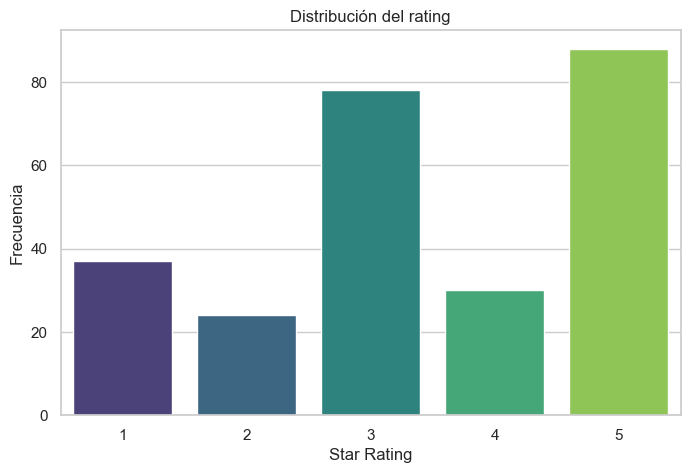

Star Rating
1    37
2    24
3    78
4    30
5    88
Name: count, dtype: int64


In [28]:
# Análisis univariante: distribución del rating
# Esto me muestra cuántas reviews hay de cada clase (1, 2, 3, 4 o 5 estrellas)
# Si una clase tiene muchas más muestras que otra, el modelo puede aprender mal
sns.countplot(data=datos, x='Star Rating', palette='viridis')
plt.title('Distribución del rating')
plt.xlabel('Star Rating')
plt.ylabel('Frecuencia')
plt.show()

# Muestro también el recuento exacto
print(datos['Star Rating'].value_counts().sort_index())

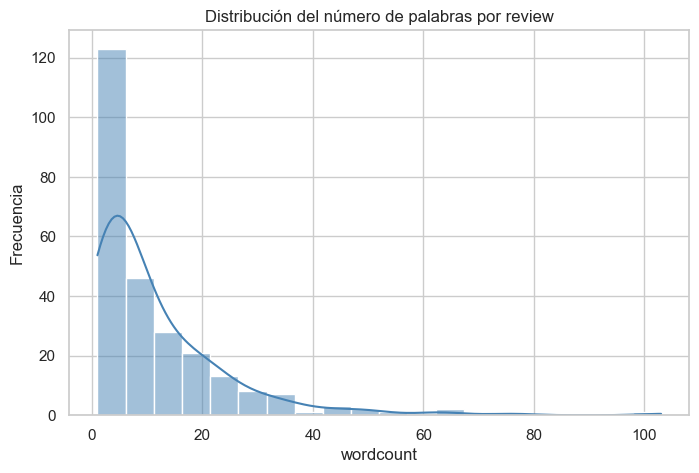

In [29]:
# Distribución de wordcount
# Me interesa saber si hay reviews muy largas que puedan ser outliers
sns.histplot(data=datos, x='wordcount', bins=20, kde=True, color='steelblue')
plt.title('Distribución del número de palabras por review')
plt.xlabel('wordcount')
plt.ylabel('Frecuencia')
plt.show()

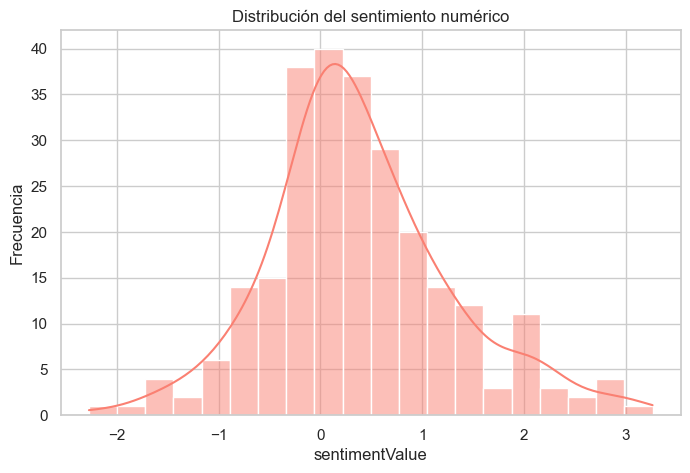

In [30]:
# Distribución de sentimentValue
# Valores negativos indican comentarios negativos, positivos indican positivos
sns.histplot(data=datos, x='sentimentValue', bins=20, kde=True, color='salmon')
plt.title('Distribución del sentimiento numérico')
plt.xlabel('sentimentValue')
plt.ylabel('Frecuencia')
plt.show()

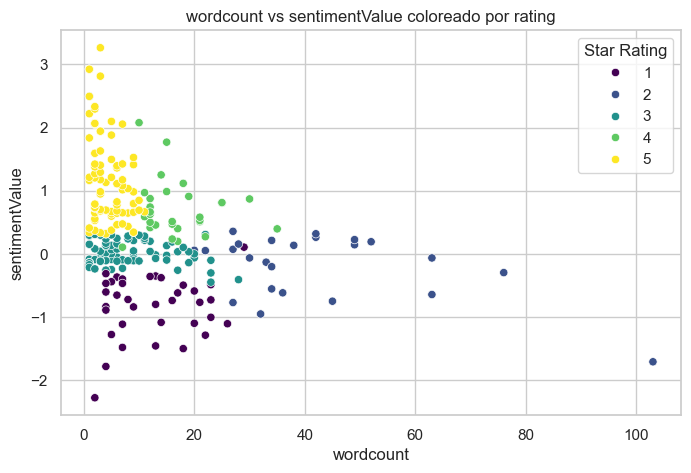

In [31]:
# Relación entre las dos variables predictoras y el rating
# Con este scatterplot veo si hay separación visual entre clases
# Si los colores se mezclan mucho, predecir será más difícil
sns.scatterplot(data=datos, x='wordcount', y='sentimentValue', hue='Star Rating', palette='viridis')
plt.title('wordcount vs sentimentValue coloreado por rating')
plt.xlabel('wordcount')
plt.ylabel('sentimentValue')
plt.show()

In [32]:
# Estadísticos descriptivos de las variables numéricas
# Me ayuda a ver rangos, medias y posibles outliers
datos[['wordcount', 'sentimentValue']].describe()

,wordcount,sentimentValue
count,257.000000,257.000000
mean,11.501946,0.383849
std,13.159812,0.897987
min,1.000000,-2.276469
25%,3.000000,-0.108144
50%,7.000000,0.264091
75%,16.000000,0.808384
max,103.000000,3.264579


## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [37]:
# Separo las variables de entrada (X) de la variable que quiero predecir (y)
# X tiene las dos columnas predictoras
# y tiene las etiquetas: las estrellas del 1 al 5
X = datos[['wordcount', 'sentimentValue']]
y = datos['Star Rating']

# Divido en conjunto de entrenamiento (80%) y conjunto de prueba (20%)
# test_size=0.2 significa que el 20% de los datos van a test y el 80% a train
# random_state=42 fija una semilla para que la división sea siempre igual y reproducible
# stratify=y asegura que la proporción de cada clase es igual en train y en test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño X_train:', X_train.shape)
print('Tamaño X_test:', X_test.shape)
print('Tamaño y_train:', y_train.shape)
print('Tamaño y_test:', y_test.shape)

Tamaño X_train: (205, 2)
Tamaño X_test: (52, 2)
Tamaño y_train: (205,)
Tamaño y_test: (52,)


In [38]:
# Creo el objeto MinMaxScaler para escalar las variables entre 0 y 1
# Esto es necesario porque KNN calcula distancias entre puntos
# Si wordcount va de 1 a 100 y sentimentValue va de -4 a 4, wordcount dominaría la distancia
# Escalando, ambas variables quedan en el mismo rango y tienen el mismo peso

scaler = MinMaxScaler()

# Ajusto el escalador SOLO con los datos de entrenamiento
# Después transformo train con los valores aprendidos de train
X_train_scaled = scaler.fit_transform(X_train)

# Transformo el test usando el mismo escalador que aprendió de train
# Si ajustara el scaler también con test, el modelo "vería" información del test antes de tiempo
X_test_scaled = scaler.transform(X_test)

# Verifico que los valores ahora están entre 0 y 1
print('Primeras filas de X_train escalado:')
print(X_train_scaled[:5])

Primeras filas de X_train escalado:
[[0.19607843 0.27272556]
 [0.         0.37238031]
 [0.24509804 0.21151239]
 [0.26470588 0.33745345]
 [0.60784314 0.29493351]]


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [39]:
# Creo el modelo KNN con k=5 como primera prueba
# n_neighbors=5 significa que al clasificar un dato nuevo miraré los 5 más cercanos
# y la clase más votada entre esos 5 será la predicción
knn = KNeighborsClassifier(n_neighbors=5)

# Entreno el modelo con los datos escalados de entrenamiento
# En KNN 'entrenar' significa guardar los ejemplos; no hay cálculo matemático complejo
knn.fit(X_train_scaled, y_train)

# Hago predicciones tanto sobre train como sobre test
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculo el accuracy: porcentaje de predicciones correctas
# Un accuracy de 0.80 significa que el modelo acierta el 80% de las veces
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)

# El error es simplemente 1 - accuracy
train_error = 1 - train_accuracy
test_error  = 1 - test_accuracy

print('Accuracy train:', round(train_accuracy, 4))
print('Accuracy test: ', round(test_accuracy,  4))
print('Error train:   ', round(train_error,    4))
print('Error test:    ', round(test_error,     4))

# Si el error de train es muy bajo pero el de test es alto, hay overfitting:
# el modelo aprendió demasiado los datos de entrenamiento y no generaliza bien

Accuracy train: 0.9073
Accuracy test:  0.9038
Error train:    0.0927
Error test:     0.0962


## Evalúa tu modelo

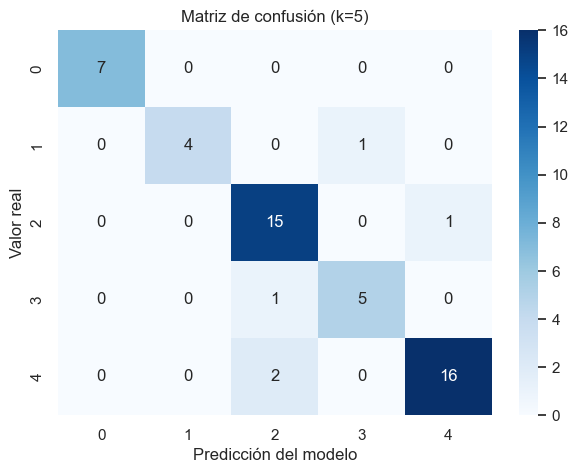

In [40]:
# La matriz de confusión muestra cuántas veces el modelo predijo cada clase
# correctamente (diagonal) y en qué clases se confundió (fuera de la diagonal)
# Por ejemplo: si una review era de 3 estrellas y el modelo predijo 2, eso aparece fuera de la diagonal
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (k=5)')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

In [41]:
# El classification_report muestra métricas por clase:
# - precision: de los que predije como clase X, cuántos eran realmente clase X
# - recall: de los que eran realmente clase X, cuántos detecté correctamente
# - f1-score: media armónica de precision y recall, un buen resumen global
# - support: cuántas muestras hay de esa clase en test
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      0.80      0.89         5
           3       0.83      0.94      0.88        16
           4       0.83      0.83      0.83         6
           5       0.94      0.89      0.91        18

    accuracy                           0.90        52
   macro avg       0.92      0.89      0.90        52
weighted avg       0.91      0.90      0.90        52



## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [43]:
# Pruebo valores de k del 1 al 30 y guardo los resultados
resultados = []

for k in range(1, 31):
    # Creo un modelo con cada valor de k
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_scaled, y_train)
    
    # Calculo accuracy tanto en train como en test para cada k
    acc_train = accuracy_score(y_train, modelo_k.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  modelo_k.predict(X_test_scaled))
    
    resultados.append([k, acc_train, acc_test])

# Convierto la lista en DataFrame para manejarla mejor
resultados_k = pd.DataFrame(resultados, columns=['k', 'accuracy_train', 'accuracy_test'])
resultados_k

,k,accuracy_train,accuracy_test
0,1,0.995122,0.884615
1,2,0.902439,0.846154
2,3,0.917073,0.903846
3,4,0.907317,0.884615
4,5,0.907317,0.903846
5,6,0.902439,0.903846
6,7,0.887805,0.884615
7,8,0.897561,0.903846
8,9,0.873171,0.884615
9,10,0.882927,0.884615


In [44]:
# Busco el valor de k que maximiza el accuracy en TEST
# Uso test y no train porque quiero el k que mejor generaliza con datos nuevos
mejor_fila    = resultados_k.loc[resultados_k['accuracy_test'].idxmax()]
mejor_k       = int(mejor_fila['k'])
mejor_accuracy = mejor_fila['accuracy_test']

print('Mejor k:', mejor_k)
print('Mejor accuracy en test con ese k:', round(mejor_accuracy, 4))

Mejor k: 3
Mejor accuracy en test con ese k: 0.9038


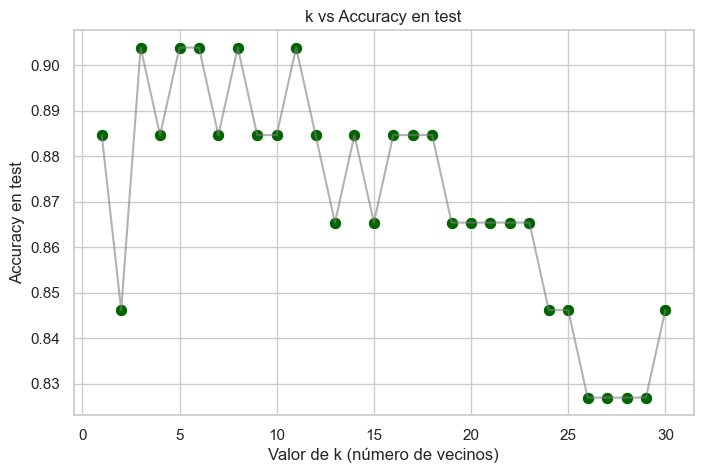

In [45]:
# Scatterplot de k vs accuracy en test
# Esto me permite ver visualmente qué k funciona mejor
sns.scatterplot(data=resultados_k, x='k', y='accuracy_test', color='darkgreen', s=80)
plt.plot(resultados_k['k'], resultados_k['accuracy_test'], color='gray', alpha=0.6)
plt.title('k vs Accuracy en test')
plt.xlabel('Valor de k (número de vecinos)')
plt.ylabel('Accuracy en test')
plt.show()

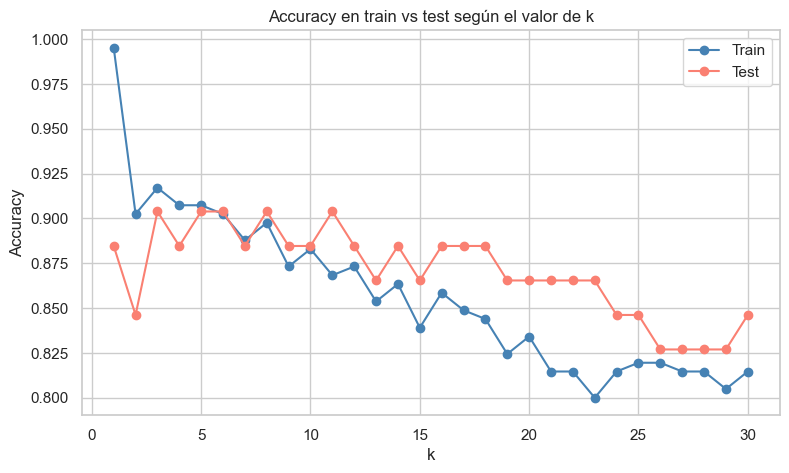

In [46]:
# También comparo el accuracy en train y en test para detectar overfitting
# Si la línea de train está muy por encima de la de test, el modelo no generaliza bien
plt.figure(figsize=(9, 5))
plt.plot(resultados_k['k'], resultados_k['accuracy_train'], marker='o', label='Train', color='steelblue')
plt.plot(resultados_k['k'], resultados_k['accuracy_test'],  marker='o', label='Test',  color='salmon')
plt.title('Accuracy en train vs test según el valor de k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [48]:
# Reentreno el modelo usando el mejor k encontrado
modelo_final = KNeighborsClassifier(n_neighbors=mejor_k)
modelo_final.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [49]:
# Creo el nuevo ejemplo con los valores del enunciado
# IMPORTANTE: debo escalar el nuevo dato con el mismo scaler que usé en train
# Si no escalo, los valores estarían en un rango distinto y la predicción sería incorrecta
nueva_review = pd.DataFrame({
    'wordcount': [5],
    'sentimentValue': [1]
})

# Aplico la misma transformación del scaler ya entrenado
nueva_review_scaled = scaler.transform(nueva_review)

# El modelo busca los k vecinos más cercanos a este nuevo punto
# y devuelve la clase más votada entre esos vecinos
prediccion = modelo_final.predict(nueva_review_scaled)

print('Para una review de 5 palabras y sentimiento 1, el modelo predice:', prediccion[0], 'estrella(s)')

Para una review de 5 palabras y sentimiento 1, el modelo predice: 5 estrella(s)
